# EarthCare ATLID Analysis 

In [28]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.interpolate import interp1d
from matplotlib.colors import ListedColormap, BoundaryNorm

<a href="https://colab.research.google.com/github/jrobrien91/agora2026-dust/blob/main/notebooks/EarthCARE_EBD_2A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# ========================================================================================================================
#                                         Variable "particle_extinction_coefficient_355nm"
# ========================================================================================================================

In [ ]:
# Uncomment if running on CoLab
##!pip install netCDF4

In [ ]:
# Uncomment if running on CoLab
##import pathlib
##from pathlib import Path
##import gdown

##DATA_LINK = "1Ek1YxH1qWZb4FRDF81vJhiqwL8mSnWhj"
##CREATE_BASE = pathlib.Path("./sample_data")
##CREATE_BASE.mkdir(parents=True, exist_ok=True)
##gdown.download(id=DATA_LINK, output=str(CREATE_BASE / "ECA_EXBC_ATL_EBD_2A_20260303T143905Z_20260303T162808Z_10015D.h5"), quiet=False)

In [ ]:

# Step 1. Read file

file_path = "./sample_data/ECA_EXBC_ATL_EBD_2A_20260303T143905Z_20260303T162808Z_10015D.h5"

ds = xr.open_dataset(
    file_path,
    engine="h5netcdf",
    group="ScienceData")

In [31]:

# Step 2. Use variables

lat = ds["latitude"].values
lon = ds["longitude"].values
time = ds["time"].values
elevation = ds["elevation"].values
height = ds["height"].values

ext = ds["particle_extinction_coefficient_355nm"].values
depol = ds["particle_linear_depol_ratio_355nm"].values # NumPy array (data only)
depol_da   = ds["particle_linear_depol_ratio_355nm"] # xarray DataArray (data + metadata)
quality = ds["quality_status"].values
simple_class = ds["simple_classification"].values

In [32]:

# Step 3. Print unit and fill values
# See what the measurement unit is and if there are any fill values in the file

ext_da = ds["particle_extinction_coefficient_355nm"]

fill_value = ext_da.attrs.get("_FillValue", None)
units = ext_da.attrs.get("units", "unknown")

print("Extinction units:", units)
print("Fill value:", fill_value)

Extinction units: m-1
Fill value: None


In [33]:

# Step 4. Location
# Badajoz, also an AERONET station

target_lat = 38.8803 
target_lon = -6.9753
radius_km = 50.0

In [34]:
# Step 5. Haversine distance
#The Haversine formula computes the distance between the target point and long/lat with every EarthCARE profile location

def haversine(lat0, lon0, lat, lon):

    r = 6371.0

    lat0 = np.radians(lat0)
    lon0 = np.radians(lon0)

    lat = np.radians(lat)
    lon = np.radians(lon)

    dlat = lat - lat0
    dlon = lon - lon0

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat0)
        * np.cos(lat)
        * np.sin(dlon / 2.0) ** 2)

    return 2 * r * np.arcsin(np.sqrt(a))

In [35]:

# Step 6. Select location-relevant profiles

distance = haversine(
    target_lat,
    target_lon,
    lat,
    lon)

mask = distance <= radius_km     #50km

if not np.any(mask):
    raise ValueError(
        f"No profiles found within {radius_km} km.")

# Subset

sub_lat = lat[mask]
sub_lon = lon[mask]
sub_time = time[mask]

sub_ext = ext[mask, :]
sub_height = height[mask, :]
sub_quality = quality[mask, :]

print(f"Profiles selected: {sub_ext.shape[0]}")

Profiles selected: 94


In [36]:

# Step 7. Handle fill values, turning them into NANs

if fill_value is not None:
    sub_ext = np.where(
        sub_ext == fill_value,
        np.nan,
        sub_ext)

In [37]:

# Step 8. Quality filtering, keeping bins with GOOD_FLAG

GOOD_FLAG = 0

sub_ext = np.where(
    sub_quality == GOOD_FLAG,
    sub_ext,
    np.nan)

In [38]:

# Step 9. Common altitude grid
#Create a common altitude grid and interpolate every profile onto this exact grid.

alt_grid = np.arange(
    500,
    10001,
    100)

n_profiles = sub_ext.shape[0]

ext_interp = np.full(
    (n_profiles, len(alt_grid)),
    np.nan)

for i in range(n_profiles):

    z = sub_height[i, :]
    e = sub_ext[i, :]

    valid = (
        np.isfinite(z)
        & np.isfinite(e))

    if valid.sum() < 5:
        continue

    f = interp1d(
        z[valid],
        e[valid],
        bounds_error=False,
        fill_value=np.nan)

    ext_interp[i, :] = f(alt_grid)

In [39]:

# Step 10. Statistics: mean, standard deviation, number of valid observations, standard error

mean_profile = np.nanmean(
    ext_interp,
    axis=0)

std_profile = np.nanstd(
    ext_interp,
    axis=0)

n_valid = np.sum(
    np.isfinite(ext_interp),
    axis=0)

stderr_profile = (
    std_profile /
    np.sqrt(np.maximum(n_valid, 1)))

start_time = np.min(sub_time)
end_time   = np.max(sub_time)
duration_minutes = (
    (end_time - start_time)
    / np.timedelta64(1, "m"))

print("Number of profiles:", n_profiles)
print(
    "Altitude range:",
    alt_grid.min(),
    alt_grid.max(),
    "m")
print(
    "Mean extinction:",
    np.nanmin(mean_profile),
    np.nanmax(mean_profile))
print(f"Start time (UTC): {start_time}")
print(f"End time (UTC): {end_time}")
print(f"Duration: {duration_minutes:.2f} minutes")

Number of profiles: 94
Altitude range: 500 10000 m
Mean extinction: 0.0 0.0006790703009526552
Start time (UTC): 2026-03-03T14:46:35.826870272
End time (UTC): 2026-03-03T14:46:49.098797056
Duration: 0.22 minutes


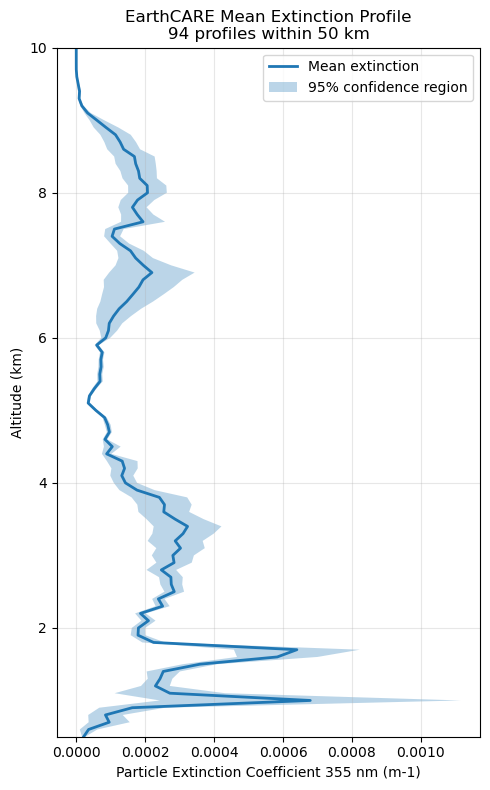

In [40]:

# Step 11. Plot profiles

fig, ax = plt.subplots(
    figsize=(5, 8))

# Convert altitude to km
alt_km = alt_grid / 1000.0

# Mean profile
ax.plot(
    mean_profile,
    alt_km,
    lw=2,
    label="Mean extinction")

# Standard error envelope
ax.fill_betweenx(
    alt_km,
    mean_profile - stderr_profile,
    mean_profile + stderr_profile,
    alpha=0.3,
    label="95% confidence region")

ax.set_xlabel(
    f"Particle Extinction Coefficient 355 nm ({units})")
ax.set_ylabel(
    "Altitude (km)")
ax.set_title(
    f"EarthCARE Mean Extinction Profile\n"
    f"{n_profiles} profiles within {radius_km:.0f} km")
ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 10)
ax.legend()

plt.tight_layout()

plt.savefig(
    "EarthCARE_mean_profile_Badajoz.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

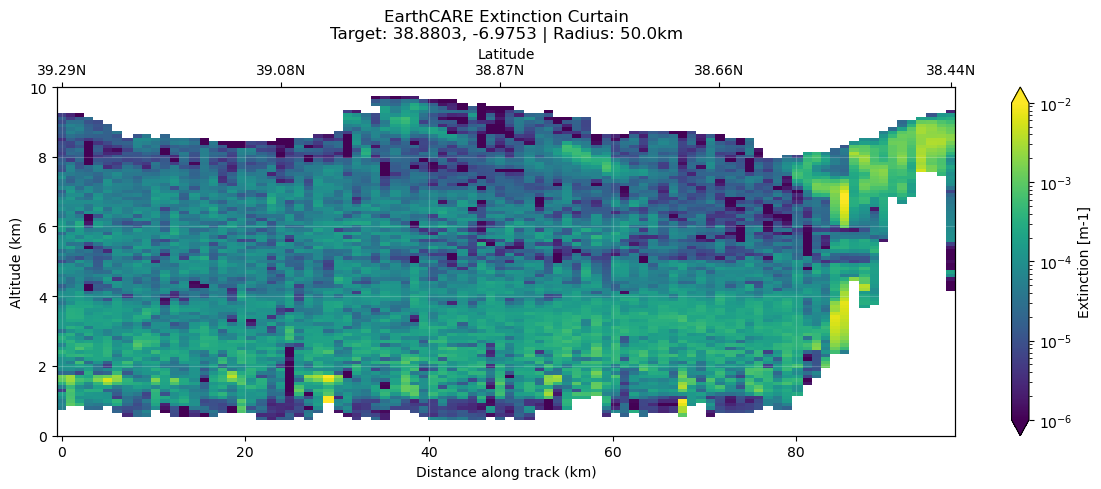

In [41]:


# Step 12. Plot Curtain Plot

# Calculate cumulative distance along the track for the X-axis
# This makes the plot more physically meaningful than just "Profile Index"
track_distances = [0]
for i in range(1, len(sub_lat)):
    d = haversine(sub_lat[i-1], sub_lon[i-1], sub_lat[i], sub_lon[i])
    track_distances.append(track_distances[-1] + d)
track_distances = np.array(track_distances)

fig, ax = plt.subplots(figsize=(12, 5))

# Create a meshgrid for plotting
# X: cumulative distance, Y: altitude in km
X, Y = np.meshgrid(track_distances, alt_grid / 1000.0)

# Transpose ext_interp to match (height, distance) shape
# We use LogNorm because lidar extinction often spans several orders of magnitude
mesh = ax.pcolormesh(
    X, Y, 
    ext_interp.T, 
    shading='auto',
    cmap='viridis',
    norm=colors.LogNorm(vmin=1e-6, vmax=1e-2) # Adjust limits based on your data
)

# Add Colorbar
cbar = fig.colorbar(mesh, ax=ax, extend='both')
cbar.set_label(f"Extinction [{units}]")

# Labels and Titles
ax.set_xlabel("Distance along track (km)")
ax.set_ylabel("Altitude (km)")
ax.set_title(
    f"EarthCARE Extinction Curtain\n"
    f"Target: {target_lat}, {target_lon} | Radius: {radius_km}km"
)

# Add a secondary X-axis at the top to show Latitude
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
tick_indices = np.linspace(0, len(sub_lat) - 1, 5, dtype=int)
ax2.set_xticks(track_distances[tick_indices])
ax2.set_xticklabels([f"{sub_lat[i]:.2f}N" for i in tick_indices])
ax2.set_xlabel("Latitude")

ax.set_ylim(0, 10) # Set height limit to 10km
ax.grid(True, alpha=0.2, color='white')

plt.tight_layout()
plt.savefig(
    "EarthCARE_extinction_curtain.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)


plt.show()

In [42]:
# ========================================================================================================================
#                                         Variable "particle_linear_depol_ratio_355nm"
# ========================================================================================================================

In [43]:
# Step 2. Inspect depol metadata

fill_depol = depol_da.attrs.get("_FillValue", None)
units_depol = depol_da.attrs.get("units", "1")   # dimensionless ratio
print("Depol units:", units_depol)
print("Depol fill value:", fill_depol)
print("Depol range in file:", np.nanmin(depol), "–", np.nanmax(depol))

Depol units: -
Depol fill value: None
Depol range in file: -1298.5358 – 24629.615


In [44]:
# Step 3. Haversine (similar to extinction variable)

def haversine(lat0, lon0, lat, lon):
    r = 6371.0
    lat0, lon0, lat, lon = map(np.radians, [lat0, lon0, lat, lon])
    dlat = lat - lat0
    dlon = lon - lon0
    a = np.sin(dlat/2)**2 + np.cos(lat0)*np.cos(lat)*np.sin(dlon/2)**2
    return 2 * r * np.arcsin(np.sqrt(a))

In [45]:

# Step 4. Spatial selection and number of available profiles

target_lat = 38.8803
target_lon = -6.9753
radius_km  = 50.0

distance = haversine(target_lat, target_lon, lat, lon)
mask = distance <= radius_km
if not np.any(mask):
    raise ValueError(f"No profiles found within {radius_km} km.")

sub_lat    = lat[mask]
sub_lon    = lon[mask]
sub_time   = time[mask]
sub_ext    = ext[mask, :]
sub_depol  = depol[mask, :]
sub_height = height[mask, :]
sub_quality = quality[mask, :]
print(f"Profiles selected: {sub_ext.shape[0]}")

Profiles selected: 94


In [46]:

# Step 5. Fill value masking

ext_da     = ds["particle_extinction_coefficient_355nm"]
fill_ext   = ext_da.attrs.get("_FillValue", None)

if fill_ext is not None:
    sub_ext = np.where(sub_ext == fill_ext, np.nan, sub_ext)
if fill_depol is not None:
    sub_depol = np.where(sub_depol == fill_depol, np.nan, sub_depol)

In [47]:

# Step 6. Quality filtering (keep GOOD_FLAG = 0 only, check EBD documentation for details)

GOOD_FLAG = 0
sub_ext   = np.where(sub_quality == GOOD_FLAG, sub_ext,  np.nan)
sub_depol = np.where(sub_quality == GOOD_FLAG, sub_depol, np.nan)

# Sanity clamp: depol is a ratio in [0, 1]; clip unphysical values
sub_depol = np.where((sub_depol >= 0) & (sub_depol <= 1), sub_depol, np.nan)

In [48]:

# Step 7. Interpolate both variables onto common altitude grid

alt_grid   = np.arange(500, 10001, 100)   # 500 m – 10 000 m, 100 m bins
n_profiles = sub_ext.shape[0]

ext_interp   = np.full((n_profiles, len(alt_grid)), np.nan)
depol_interp = np.full((n_profiles, len(alt_grid)), np.nan)

for i in range(n_profiles):
    z = sub_height[i, :]
    e = sub_ext[i, :]
    d = sub_depol[i, :]

    valid_e = np.isfinite(z) & np.isfinite(e)
    valid_d = np.isfinite(z) & np.isfinite(d)

    if valid_e.sum() >= 5:
        ext_interp[i, :]   = interp1d(z[valid_e], e[valid_e],
                                       bounds_error=False, fill_value=np.nan)(alt_grid)
    if valid_d.sum() >= 5:
        depol_interp[i, :] = interp1d(z[valid_d], d[valid_d],
                                       bounds_error=False, fill_value=np.nan)(alt_grid)

In [49]:
# Step 8. Profile statistics

def profile_stats(arr):
    mean   = np.nanmean(arr, axis=0)
    std    = np.nanstd(arr, axis=0)
    n      = np.sum(np.isfinite(arr), axis=0)
    stderr = std / np.sqrt(np.maximum(n, 1))
    return mean, std, n, stderr

mean_ext,   _, _, stderr_ext   = profile_stats(ext_interp)
mean_depol, _, _, stderr_depol = profile_stats(depol_interp)

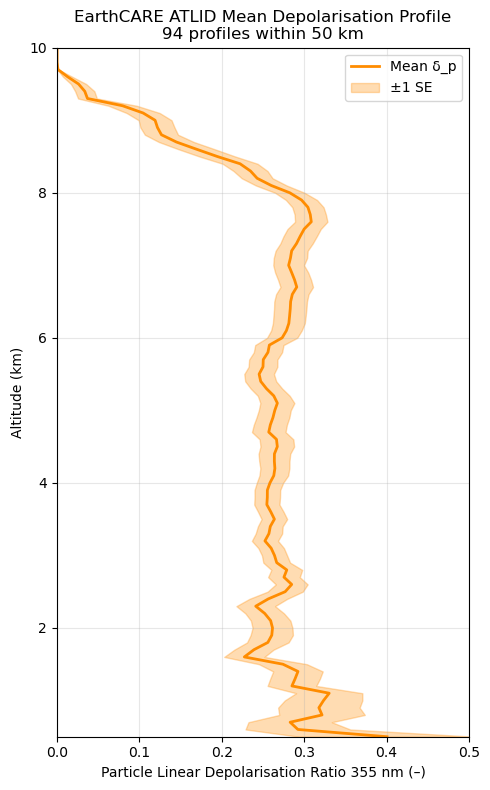

In [50]:
# Step 9. Plot Mean depolarisation vertical profile

alt_km = alt_grid / 1000.0

fig, ax = plt.subplots(figsize=(5, 8))
ax.plot(mean_depol, alt_km, color="darkorange", lw=2, label="Mean δ_p")
ax.fill_betweenx(alt_km,
                 mean_depol - stderr_depol,
                 mean_depol + stderr_depol,
                 alpha=0.3, color="darkorange", label="±1 SE")
ax.set_xlabel("Particle Linear Depolarisation Ratio 355 nm (–)")
ax.set_ylabel("Altitude (km)")
ax.set_title(f"EarthCARE ATLID Mean Depolarisation Profile\n"
             f"{n_profiles} profiles within {radius_km:.0f} km")
ax.set_xlim(0, 0.5)   # physical range; widen if data demands it
ax.set_ylim(0.5, 10)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("EarthCARE_depol_profile.png", dpi=300, bbox_inches="tight")
plt.show()

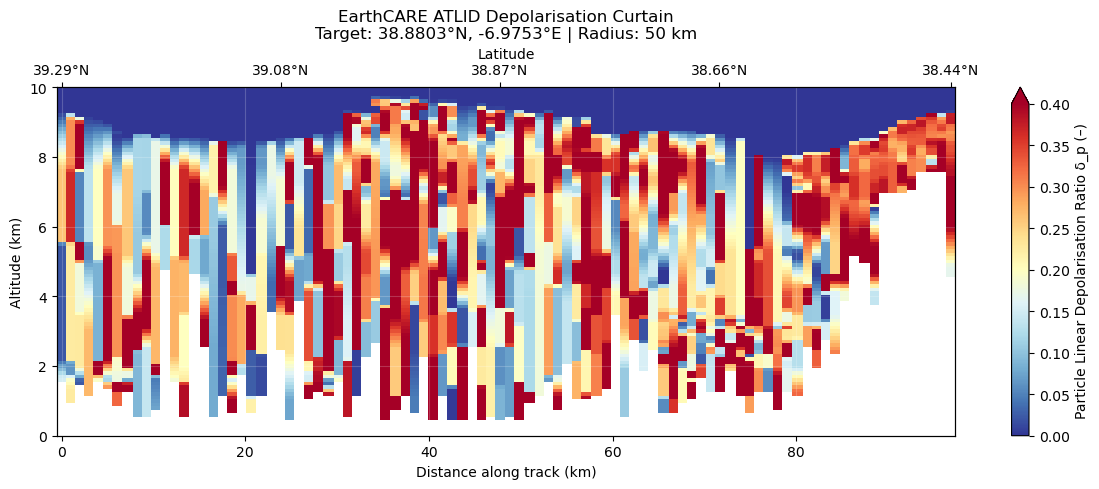

In [51]:
# Step 10. Plot Depolarisation curtain plot

track_distances = [0]
for i in range(1, len(sub_lat)):
    d = haversine(sub_lat[i-1], sub_lon[i-1], sub_lat[i], sub_lon[i])
    track_distances.append(track_distances[-1] + d)
track_distances = np.array(track_distances)

X, Y = np.meshgrid(track_distances, alt_km)

fig, ax = plt.subplots(figsize=(12, 5))
mesh = ax.pcolormesh(X, Y, depol_interp.T,
                     shading="auto",
                     cmap="RdYlBu_r",       # red = high depol (dust/ice), blue = low (spherical)
                     vmin=0, vmax=0.4)       # linear scale — depol is already bounded
cbar = fig.colorbar(mesh, ax=ax, extend="max")
cbar.set_label("Particle Linear Depolarisation Ratio δ_p (–)")

ax.set_xlabel("Distance along track (km)")
ax.set_ylabel("Altitude (km)")
ax.set_title(f"EarthCARE ATLID Depolarisation Curtain\n"
             f"Target: {target_lat}°N, {target_lon}°E | Radius: {radius_km:.0f} km")
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.2, color="white")

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
tick_idx = np.linspace(0, len(sub_lat) - 1, 5, dtype=int)
ax2.set_xticks(track_distances[tick_idx])
ax2.set_xticklabels([f"{sub_lat[i]:.2f}°N" for i in tick_idx])
ax2.set_xlabel("Latitude")

plt.tight_layout()
plt.savefig("EarthCARE_depol_curtain.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/d5/z8x0rw3j40l80p20h7q5kcz00000gn/T/ipykernel_8168/44843097.py:34: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(


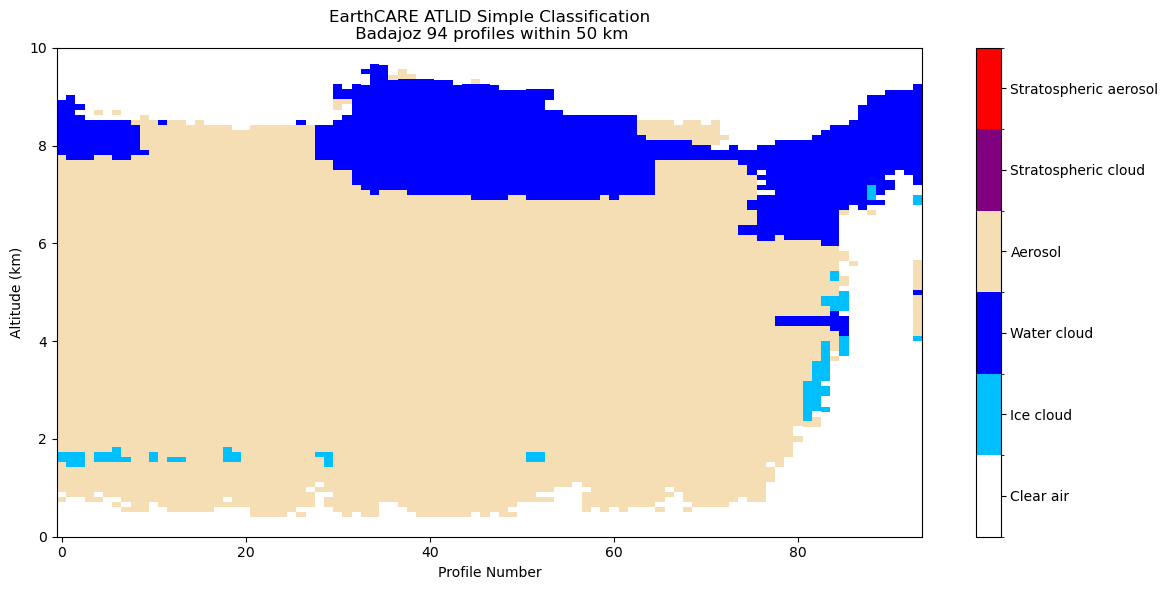

In [53]:
# ========================================================================================================================
#                                         Variable "simple_classification"
# ========================================================================================================================

sub_class = simple_class[mask, :]

# Define class labels
class_labels = {
     0: "Clear air",
     1: "Ice cloud",
     2: "Water cloud",
     3: "Aerosol",
     4: "Stratospheric cloud",
     5: "Stratospheric aerosol"}

colors = [
    "white",       #  0 Clear
    "deepskyblue", #  1 Ice
    "blue",        #  2 Water
    "wheat",      #  3 Aerosol
    "purple",      #  4 Stratospheric cloud
    "red"]          #  5 Stratospheric aerosol

cmap = ListedColormap(colors)
norm = BoundaryNorm(
    np.arange(-0.5, len(colors)+0.5),
    cmap.N)

# Plot curtain
fig, ax = plt.subplots(figsize=(12,6))

pcm = ax.pcolormesh(
    np.arange(sub_class.shape[0]),
    sub_height.T / 1000.0,
    sub_class.T,
    shading="auto",
    cmap=cmap,
    norm=norm)

cbar = plt.colorbar(
    pcm,
    ticks=list(class_labels.keys()))

cbar.ax.set_yticklabels(
    [class_labels[k] for k in class_labels])

ax.set_xlabel("Profile Number")
ax.set_ylabel("Altitude (km)")

ax.set_title(
    f"EarthCARE ATLID Simple Classification\n Badajoz "
    f"{sub_class.shape[0]} profiles within {radius_km:.0f} km")

ax.set_ylim(0,10)

plt.tight_layout()

plt.savefig(
    "EarthCARE_simple_classification.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05)

plt.show()